#Are High-Paid Running Backs Worth It? A NFL Cap Analysis (2011 - 2025)

#Introduciton


In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

#Connect to the database
conn = sqlite3.connect('database/rb_analysis.db')

#Reusable formatting function
def format_df(df):
    df = df.copy()
    if 'contract_average' in df.columns:
        df['contract_average'] = df['contract_average'].apply(lambda x: '${:,.0f}'.format(float(x)) if x != 'DNQ' else x)
    if 'cap_hit' in df.columns:
        df['cap_hit'] = df['cap_hit'].apply(lambda x: '${:,.0f}'.format(float(x)) if x != 'DNQ' else x)
    if 'cap_percentage' in df.columns:
        df['cap_percentage'] = df['cap_percentage'].apply(lambda x: '{}%'.format(x) if x != 'DNQ' and not str(x).endswith('%') else x)
    return df

## Data Overview
The dataset consists of two tables:
- **rb_top_5** — top paid running backs each season by contract average and/or cap hit
- **team_data** — season outcomes for those teams including wins, losses, and playoff result

Data spans from **2011 to 2025** — chosen because the 2011 CBA introduced the current rookie wage scale and standardized contract structures, making salary comparisons consistent across all seasons.

In [2]:
#Preview rb_top_5 table
print("=== RB TOP 5 ===")
rb_df = pd.read_sql("SELECT * FROM rb_top_5 LIMIT 10", conn)
print(format_df(rb_df).to_string())

# Preview team_data table
print("\n=== TEAM DATA ===")
team_df = pd.read_sql("SELECT * FROM team_data LIMIT 10", conn)
print(team_df.to_string())

=== RB TOP 5 ===
           player_name team  season contract_average      cap_hit cap_percentage
0       Saquon Barkley  PHI    2025      $20,600,000          DNQ            DNQ
1  Christian McCaffrey   SF    2025      $19,000,000          DNQ            DNQ
2        Derrick Henry  BAL    2025      $15,000,000          DNQ            DNQ
3      Jonathan Taylor  IND    2025      $14,000,000  $15,564,520          6.23%
4         Alvin Kamara   NO    2025      $12,250,000   $9,708,471           4.8%
5          Josh Jacobs   GB    2025              DNQ  $11,325,000           4.7%
6            Joe Mixon  HOU    2025              DNQ   $9,420,270          3.33%
7        D'Andre Swift  CHI    2025              DNQ   $9,333,333          3.13%
8  Christian McCaffrey   SF    2024      $19,000,000   $6,329,647          7.44%
9      Jonathan Taylor  IND    2024      $14,000,000  $10,666,000          6.23%

=== TEAM DATA ===
  team  season  wins  losses  Tie made_playoffs   playoff_result
0  PHI  

## Analysis
Now we join both tables to examine how teams with a top-paid running back actually performed each season.

In [3]:
#Join both tables to see RB salary vs team outcome
query = '''
    SELECT 
        r.player_name,
        r.team,
        r.season,
        r.contract_average,
        r.cap_hit,
        r.cap_percentage,
        t.wins,
        t.losses,
        t.made_playoffs,
        t.playoff_result
    FROM rb_top_5 r
    JOIN team_data t ON r.team = t.team AND r.season = t.season
    ORDER BY r.season DESC
'''
df = pd.read_sql(query, conn)
format_df(df)

,player_name,team,season,contract_average,cap_hit,cap_percentage,wins,losses,made_playoffs,playoff_result
0,Saquon Barkley,PHI,2025,"$20,600,000",DNQ,DNQ,11,6,Yes,Wild Card
1,Christian McCaffrey,SF,2025,"$19,000,000",DNQ,DNQ,12,5,Yes,Divisional
2,Derrick Henry,BAL,2025,"$15,000,000",DNQ,DNQ,8,9,No,Missed Playoffs
3,Jonathan Taylor,IND,2025,"$14,000,000","$15,564,520",6.23%,8,9,No,Missed Playoffs
4,Alvin Kamara,NO,2025,"$12,250,000","$9,708,471",4.8%,6,11,No,Missed Playoffs
...,...,...,...,...,...,...,...,...,...,...
100,Chris Johnson,TEN,2011,"$13,493,750",DNQ,DNQ,9,7,No,Missed Playoffs
101,DeAngelo Williams,CAR,2011,"$8,600,000","$7,700,000",7.14%,6,10,No,Missed Playoffs
102,Steven Jackson,STL,2011,"$7,467,500","$9,479,000",6.44%,2,14,No,Missed Playoffs
103,Darren McFadden,OAK,2011,"$7,007,292","$10,873,833",6.04%,8,8,No,Missed Playoffs


## Key Findings

### Finding 1: Most teams with a top-paid RB missed the playoffs
Nearly 2 out of every 3 teams that committed significant money to a running back failed to even make the playoffs that season.

In [4]:
#Playoff outcome distribution
query = '''
    SELECT 
        playoff_result as outcome,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM team_data), 2) as percentage
    FROM team_data
    GROUP BY outcome
    ORDER BY count DESC
'''
df_outcomes = pd.read_sql(query, conn)
df_outcomes['percentage'] = df_outcomes['percentage'].apply(lambda x: '{}%'.format(x))
df_outcomes

,outcome,count,percentage
0,Missed Playoffs,67,63.81%
1,Wild Card,16,15.24%
2,Divisional,14,13.33%
3,Super Bowl Loss,5,4.76%
4,Conference Championship,2,1.9%
5,Super Bowl Win,1,0.95%


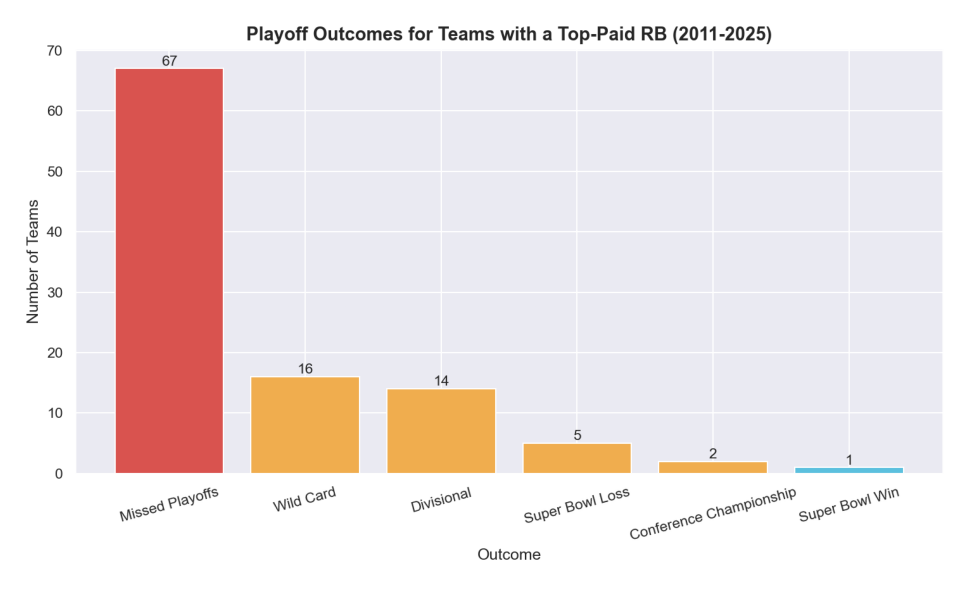

In [5]:
#Chart 1: Playoff Outcome Distribution
img = plt.imread('charts/chart1_outcome_distribution.png')
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### Finding 2: Only 1 out of 105 team seasons resulted in a Super Bowl win
The 2024 Philadelphia Eagles with Saquon Barkley are the only team in this dataset to win the Super Bowl while having a top-paid running back since 2011. radda radda

In [6]:
#Super Bowl wins by top paid RB teams
query = '''
    SELECT 
        COUNT(*) as total_team_seasons,
        SUM(CASE WHEN playoff_result = 'Super Bowl Win' THEN 1 ELSE 0 END) as super_bowl_wins,
        ROUND(SUM(CASE WHEN playoff_result = 'Super Bowl Win' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as win_percentage
    FROM team_data
'''
df_sb = pd.read_sql(query, conn)
df_sb['win_percentage'] = df_sb['win_percentage'].apply(lambda x: '{}%'.format(x))
df_sb

,total_team_seasons,super_bowl_wins,win_percentage
0,105,1,0.95%


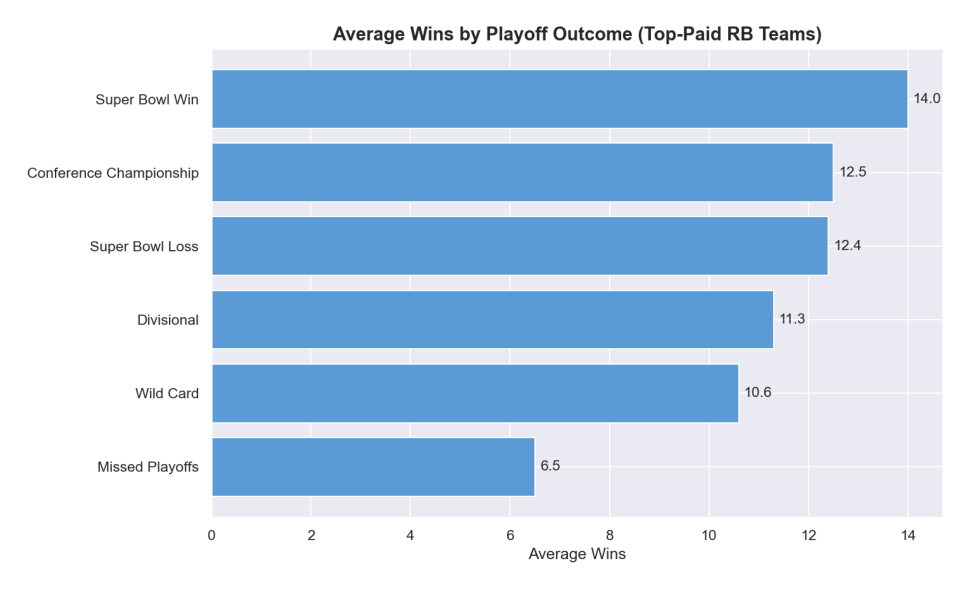

In [7]:
#Chart 2: Average Wins by Playoff Result
img = plt.imread('charts/chart2_avg_wins.png')
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### Finding 3: Paying more at RB does not correlate with more wins
Teams that missed the playoffs had a higher average cap hit at RB than teams that made the Super Bowl. radda radda

In [8]:
# Average cap hit by playoff result
query = '''
    SELECT 
        t.playoff_result as outcome,
        ROUND(AVG(r.cap_hit), 2) as avg_cap_hit,
        ROUND(AVG(r.cap_percentage), 2) as avg_cap_percentage
    FROM rb_top_5 r
    JOIN team_data t ON r.team = t.team AND r.season = t.season
    GROUP BY outcome
    ORDER BY avg_cap_hit DESC
'''
df_cap = pd.read_sql(query, conn)
df_cap['avg_cap_hit'] = df_cap['avg_cap_hit'].apply(lambda x: '${:,.0f}'.format(x) if pd.notnull(x) else 'N/A')
df_cap['avg_cap_percentage'] = df_cap['avg_cap_percentage'].apply(lambda x: '{}%'.format(x) if pd.notnull(x) else 'N/A')
df_cap

,outcome,avg_cap_hit,avg_cap_percentage
0,Wild Card,"$7,489,938",4.9%
1,Missed Playoffs,"$7,081,793",4.67%
2,Super Bowl Loss,"$6,330,955",5.29%
3,Divisional,"$5,987,143",2.38%
4,Conference Championship,"$5,710,294",3.02%
5,Super Bowl Win,$0,0.0%


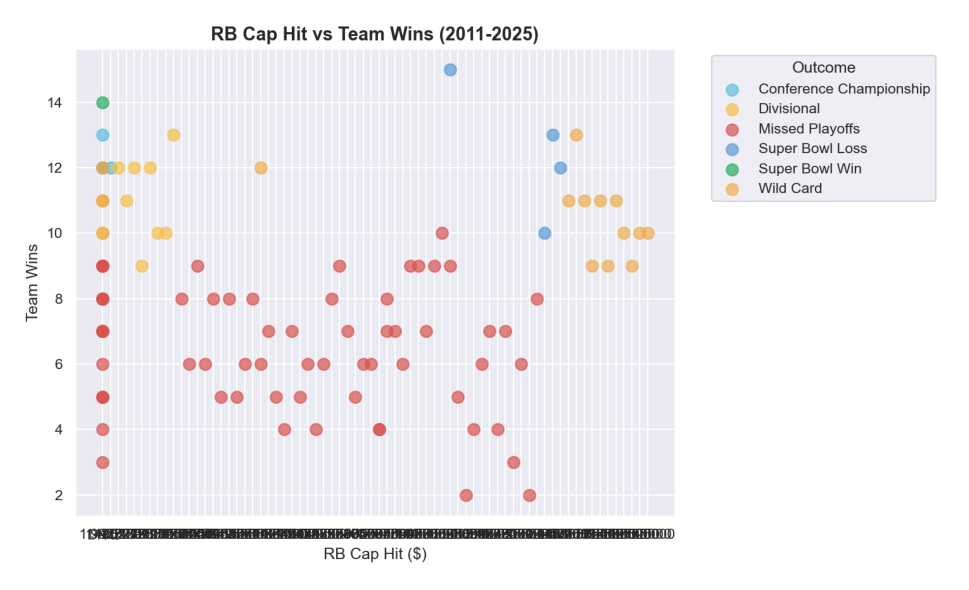

In [9]:
#Chart 3: Cap Hit vs Wins Scatter Plot
img = plt.imread('charts/chart3_caphit_vs_wins.png')
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### Finding 4: The trend has not improved over time
Even as NFL teams have become more analytics driven, the pattern remains consistent — teams continue to overpay at running back and underperform as a result. radda radda

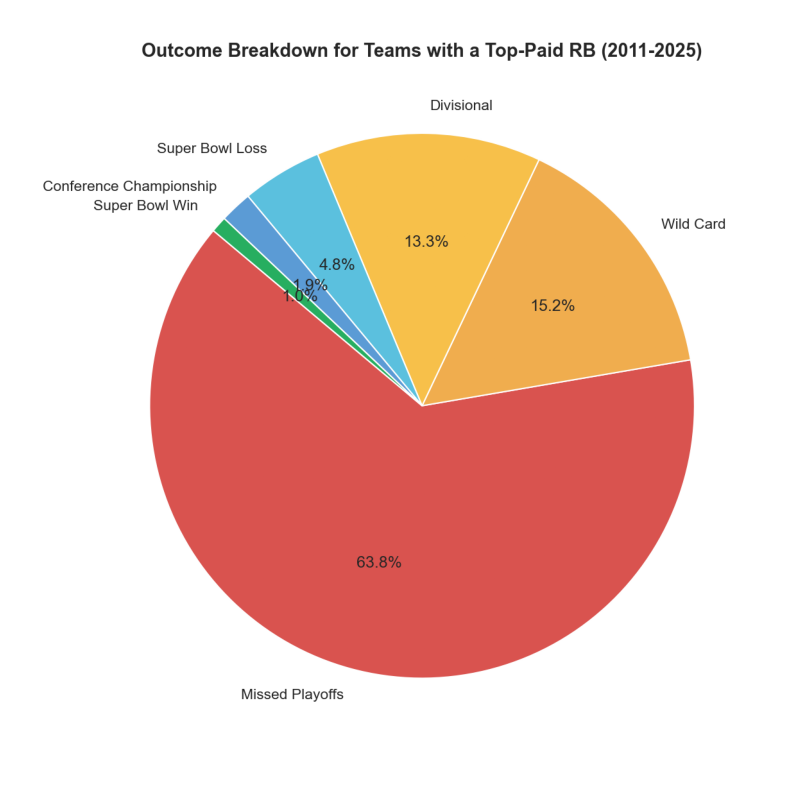

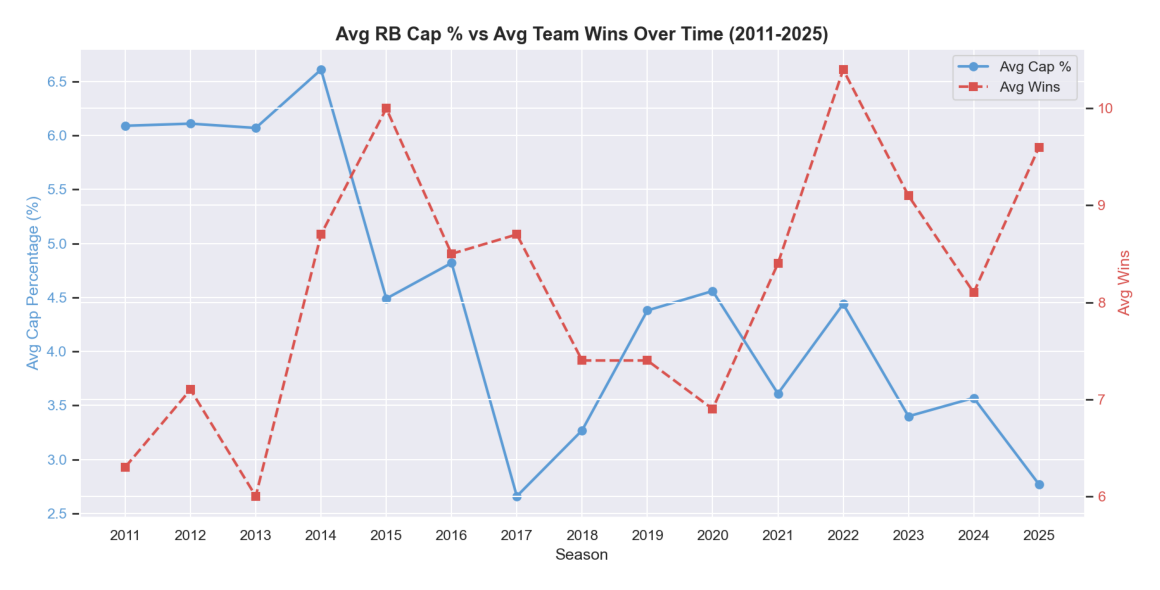

In [10]:
#Chart 4: Pie Chart Outcome Breakdown
img = plt.imread('charts/chart4_pie_outcomes.png')
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

#Chart 5: Cap Percentage Over Time
img = plt.imread('charts/chart5_cap_pct_over_time.png')
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

###Finding 5: Super Bowl winning teams paid their RB nearly half of what top paid RB teams committed
When comparing the average RB cap hit of every Super Bowl winning team since 2011 against the top paid RB teams in this dataset, the gap is significant. Super Bowl winning teams paid their running back an average of $3,256,230 (2.43% of cap), while top paid RB teams committed an average of $6,868,709 (4.36% of cap). This suggests that championship rosters are built by spending efficiently at running back, not by paying a premium for the position.

In [11]:
#Super Bowl winning teams RB cap vs top paid RB teams cap
query = '''
    SELECT 
        'Super Bowl Winners' as group_name,
        ROUND(AVG(cap_hit), 2) as avg_cap_hit,
        ROUND(AVG(cap_percentage), 2) as avg_cap_percentage
    FROM sb_winners_rb
    UNION ALL
    SELECT 
        'Top Paid RB Teams' as group_name,
        ROUND(AVG(cap_hit), 2) as avg_cap_hit,
        ROUND(AVG(cap_percentage), 2) as avg_cap_percentage
    FROM rb_top_5
'''
df_comparison = pd.read_sql(query, conn)
df_comparison['avg_cap_hit'] = df_comparison['avg_cap_hit'].apply(lambda x: '${:,.0f}'.format(x))
df_comparison['avg_cap_percentage'] = df_comparison['avg_cap_percentage'].apply(lambda x: '{}%'.format(x))
df_comparison

,group_name,avg_cap_hit,avg_cap_percentage
0,Super Bowl Winners,"$3,256,231",2.43%
1,Top Paid RB Teams,"$6,868,709",4.36%


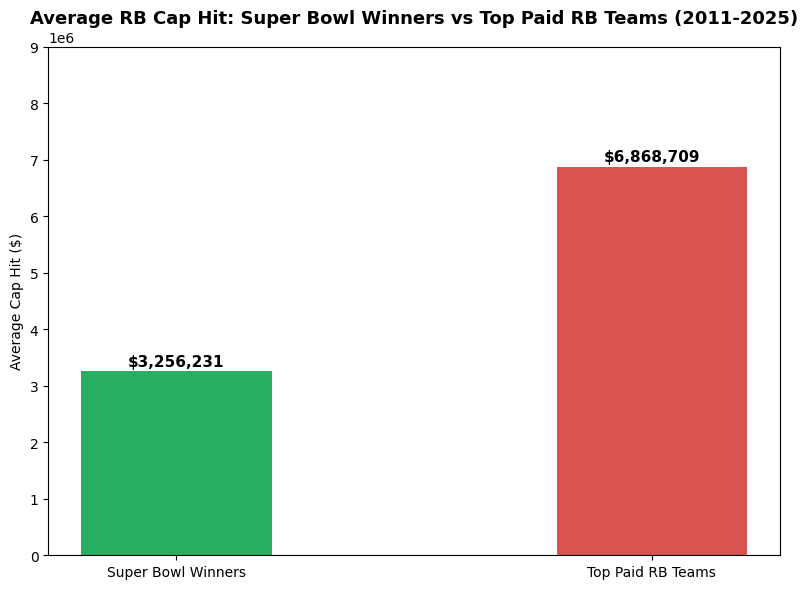

In [12]:
#Chart 6: Super Bowl Winners vs Top Paid RB Teams Cap Hit Comparison
categories = ['Super Bowl Winners', 'Top Paid RB Teams']
avg_cap_hits = [3256230.60, 6868709.22]
colors = ['#27ae60', '#d9534f']

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, avg_cap_hits, color=colors, width=0.4)
plt.title('Average RB Cap Hit: Super Bowl Winners vs Top Paid RB Teams (2011-2025)', fontsize=13, fontweight='bold')
plt.ylabel('Average Cap Hit ($)')
plt.ylim(0, 9000000)
for bar, val in zip(bars, avg_cap_hits):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100000, '${:,.0f}'.format(val), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart6_sb_vs_toppaid.png', dpi=150)
plt.show()

## Conclusion

The data tells a clear and consistent story radda radda

**Key takeaways:**
- **63.81%** of teams with a top-paid RB missed the playoffs entirely
- Only **0.95%** of team seasons resulted in a Super Bowl win
- Teams that missed the playoffs had a higher average RB cap hit than Super Bowl teams
- The one exception - the 2024 Philadelphia Eagles - only qualified by contract average, not cap hit
- Super Bowl winning teams paid their RB an average of **$3,256,230 (2.43% of cap)** — nearly half of what top paid RB teams committed at **$6,868,709 (4.36% of cap)**

This analysis supports radda radda

In [13]:
#Close database connection
conn.close()